In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import os

df = pd.read_csv("../data/processed/final_dataset.csv")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")

Shape: (11225, 18)

Columns: ['lat', 'lon', 'District', 'TEHSIL', 'elevation', 'slope', 'aspect', 'roughness', 'dist_to_road', 'dist_to_building', 'dist_to_river', 'building_density', 'landuse_type', 'ndvi', 'rainfall_7day', 'rainfall_15day', 'label', 'Exposure']

Data types:
lat                 float64
lon                 float64
District             object
TEHSIL               object
elevation             int64
slope               float64
aspect              float64
roughness           float64
dist_to_road        float64
dist_to_building    float64
dist_to_river       float64
building_density      int64
landuse_type         object
ndvi                float64
rainfall_7day       float64
rainfall_15day      float64
label                 int64
Exposure             object
dtype: object


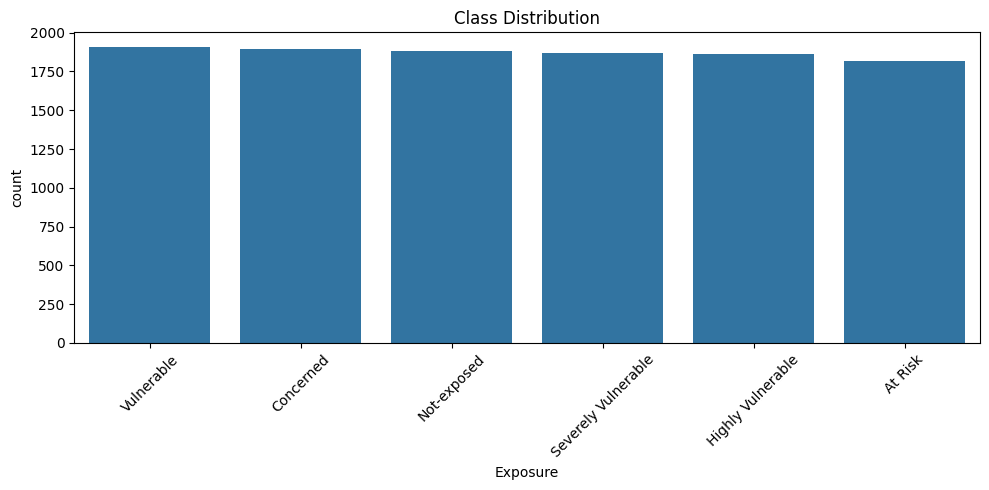

label
0    1879
1    1893
2    1815
3    1907
4    1869
5    1862
Name: count, dtype: int64


In [3]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Exposure', order=df['Exposure'].value_counts().index)
plt.title('Class Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/figures/class_distribution.png")
plt.show()

print(df['label'].value_counts().sort_index())

In [4]:
# Check unique landuse values
print("Landuse types:")
print(df['landuse_type'].value_counts())

# One hot encode
df_encoded = pd.get_dummies(df, columns=['landuse_type'], prefix='landuse')
print(f"\nShape after encoding: {df_encoded.shape}")
print(f"New columns: {[c for c in df_encoded.columns if 'landuse' in c]}")

Landuse types:
landuse_type
forest               8416
residential          1989
farmland              215
industrial            151
nature_reserve        123
park                   62
military               48
commercial             46
scrub                  39
recreation_ground      34
retail                 29
meadow                 21
orchard                15
quarry                 15
heath                  14
grass                   7
cemetery                1
Name: count, dtype: int64

Shape after encoding: (11225, 34)
New columns: ['landuse_cemetery', 'landuse_commercial', 'landuse_farmland', 'landuse_forest', 'landuse_grass', 'landuse_heath', 'landuse_industrial', 'landuse_meadow', 'landuse_military', 'landuse_nature_reserve', 'landuse_orchard', 'landuse_park', 'landuse_quarry', 'landuse_recreation_ground', 'landuse_residential', 'landuse_retail', 'landuse_scrub']


In [5]:
# Group rare landuse types before encoding
rare_threshold = 30  # anything below 30 rows = rare

landuse_counts = df['landuse_type'].value_counts()
rare_types = landuse_counts[landuse_counts < rare_threshold].index

df['landuse_type'] = df['landuse_type'].apply(
    lambda x: 'other' if x in rare_types else x
)

print("Landuse after grouping:")
print(df['landuse_type'].value_counts())

# Now encode
df_encoded = pd.get_dummies(df, columns=['landuse_type'], prefix='landuse')
print(f"\nShape after encoding: {df_encoded.shape}")
print(f"New columns: {[c for c in df_encoded.columns if 'landuse' in c]}")

Landuse after grouping:
landuse_type
forest               8416
residential          1989
farmland              215
industrial            151
nature_reserve        123
other                 102
park                   62
military               48
commercial             46
scrub                  39
recreation_ground      34
Name: count, dtype: int64

Shape after encoding: (11225, 28)
New columns: ['landuse_commercial', 'landuse_farmland', 'landuse_forest', 'landuse_industrial', 'landuse_military', 'landuse_nature_reserve', 'landuse_other', 'landuse_park', 'landuse_recreation_ground', 'landuse_residential', 'landuse_scrub']


In [6]:
drop_cols = ['lat', 'lon', 'District', 'TEHSIL', 'Exposure']

X = df_encoded.drop(drop_cols + ['label'], axis=1)
y = df_encoded['label']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns:\n{X.columns.tolist()}")

Features shape: (11225, 22)
Target shape: (11225,)

Feature columns:
['elevation', 'slope', 'aspect', 'roughness', 'dist_to_road', 'dist_to_building', 'dist_to_river', 'building_density', 'ndvi', 'rainfall_7day', 'rainfall_15day', 'landuse_commercial', 'landuse_farmland', 'landuse_forest', 'landuse_industrial', 'landuse_military', 'landuse_nature_reserve', 'landuse_other', 'landuse_park', 'landuse_recreation_ground', 'landuse_residential', 'landuse_scrub']


In [7]:
from sklearn.preprocessing import StandardScaler
import pickle

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("✅ Features scaled")

os.makedirs("../outputs/models", exist_ok=True)
with open("../outputs/models/scaler.pkl", 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Scaler saved")

✅ Features scaled
✅ Scaler saved


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set:   {X_train.shape}")
print(f"Test set:       {X_test.shape}")
print(f"\nTrain class distribution:\n{y_train.value_counts().sort_index()}")
print(f"\nTest class distribution:\n{y_test.value_counts().sort_index()}")

Training set:   (8980, 22)
Test set:       (2245, 22)

Train class distribution:
label
0    1503
1    1514
2    1452
3    1526
4    1495
5    1490
Name: count, dtype: int64

Test class distribution:
label
0    376
1    379
2    363
3    381
4    374
5    372
Name: count, dtype: int64


In [9]:
X_train.to_csv("../data/processed/X_train.csv", index=False)
X_test.to_csv("../data/processed/X_test.csv", index=False)
y_train.to_csv("../data/processed/y_train.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)

print("✅ All preprocessed data saved!")
print(f"Total features: {X_train.shape[1]}")

✅ All preprocessed data saved!
Total features: 22
